In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

METRIC_COLS = [
    "train_time_sec",
    "inference_time_sec",
    "val_top1",
    "val_top5",
    "val_macro_ap",
    "test_top1",
    "test_top5",
    "test_macro_ap",
    "final_train_loss",
    "final_val_loss",
    "best_val_loss",
    "best_epoch",
    "params_total",
    "params_trainable",
    "flops",
    "train_time_hours",
    "inference_time_ms",
]

PERCENT_COLS = [
    "val_top1",
    "val_top5",
    "val_macro_ap",
    "test_top1",
    "test_top5",
    "test_macro_ap"
]


def format_model_names(df):
    name_map = {
        "sift+svm": "SIFT + SVM",
        "hog+svm": "HOG + SVM",
        "vit_b_16": "ViT-B/16",
        "resnet50": "ResNet50",
    }
    df = df.copy()
    df["model_name"] = df["model_name"].replace(name_map)
    return df


def convert_metrics_to_percent(df):
    df = df.copy()
    for col in PERCENT_COLS:
        if col in df.columns:
            df[col] = df[col] * 100
    return df


def convert_train_time(df):
    df = df.copy()
    df["train_time_hours"] = df["train_time_sec"] / 3600
    df["train_time_min"] = df["train_time_sec"] / 60
    return df


def convert_inference_time(df):
    df = df.copy()
    df["inference_time_ms"] = df["inference_time_sec"] * 1000
    return df


def format_train_time(sec):
    h = int(sec // 3600)
    m = int((sec % 3600) // 60)
    s = int(sec % 60)
    return f"{h}h {m}m {s}s"


def load_results(path):
    df = pd.read_csv(path)
    df = format_model_names(df)
    df = convert_metrics_to_percent(df)
    df = convert_train_time(df)
    df = convert_inference_time(df)
    return df


def create_mean_table(df):
    summary = (
        df.groupby("model_name")[METRIC_COLS]
        .mean()
        .sort_values("test_top1", ascending=False)
        .reset_index()
    )

    summary["train_time"] = summary["train_time_sec"].apply(format_train_time)

    ordered_cols = [
    "model_name",
    "test_top1",
    "test_top5",
    "test_macro_ap",
    "val_top1",
    "val_top5",
    "val_macro_ap",
    "train_time_min",
    "train_time",
    "final_train_loss",
    "final_val_loss",
    "best_val_loss",
    "best_epoch",
    "params_total",
    "params_trainable",
    "flops",
]

    existing_cols = [col for col in ordered_cols if col in summary.columns]
    return summary[existing_cols]

def plot_accuracy_comparison(mean_table):
    plot_df = mean_table.set_index("model_name")[["test_top1", "test_top5", "test_macro_ap"]]
    plot_df = plot_df.sort_values("test_top1", ascending=False)
    plot_df.plot.bar(figsize=(10, 6))
    plt.title("Porovnanie metrík")
    plt.ylabel("Hodnota [%]")
    plt.xlabel("Model")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def run_full_analysis(path, dataset_title):
    df = load_results(path)

    mean_table = create_mean_table(df)
    display(mean_table.round(2))
    plot_accuracy_comparison(mean_table)

    return df, mean_table


**CIFAR-100**

Najlepší Top-1 Acc : ResNet50 - 58.40%

Najhorší Top-1 Acc : SIFT + SVM - 7.36%

Najlepší Top-5 Acc : ResNet50 - 83.49%

Najhorší Top-5 Acc : SIFT + SVM - 22.03%

Najlepšie mAP : Resnet50 - 60.95%

Najhoršie mAP : SIFT + SVM - 4.16%

Najdlhšie trénovanie: ViT-B/16 - 1h 0m 0s

Najkratšie trénovanie: SIFT + SVM - 0h 0m 39s

,model_name,test_top1,test_top5,test_macro_ap,val_top1,val_top5,val_macro_ap,train_time,final_train_loss,final_val_loss,best_val_loss,best_epoch,params_total,params_trainable,flops
0,ResNet50,58.40,83.49,60.95,59.75,85.45,64.17,0h 39m 6s,0.25,2.77,1.97,15.00,23712932.0,23712932.0,84071424.0
1,ViT-B/16,33.09,61.04,30.55,33.87,61.95,32.67,1h 0m 0s,0.15,5.04,3.30,17.33,85875556.0,85875556.0,427589376.0
2,HOG + SVM,19.02,41.69,15.84,18.80,40.55,15.91,0h 5m 11s,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SIFT + SVM,7.36,22.03,4.16,7.34,21.31,4.34,0h 0m 39s,NaN,NaN,NaN,NaN,NaN,NaN,NaN


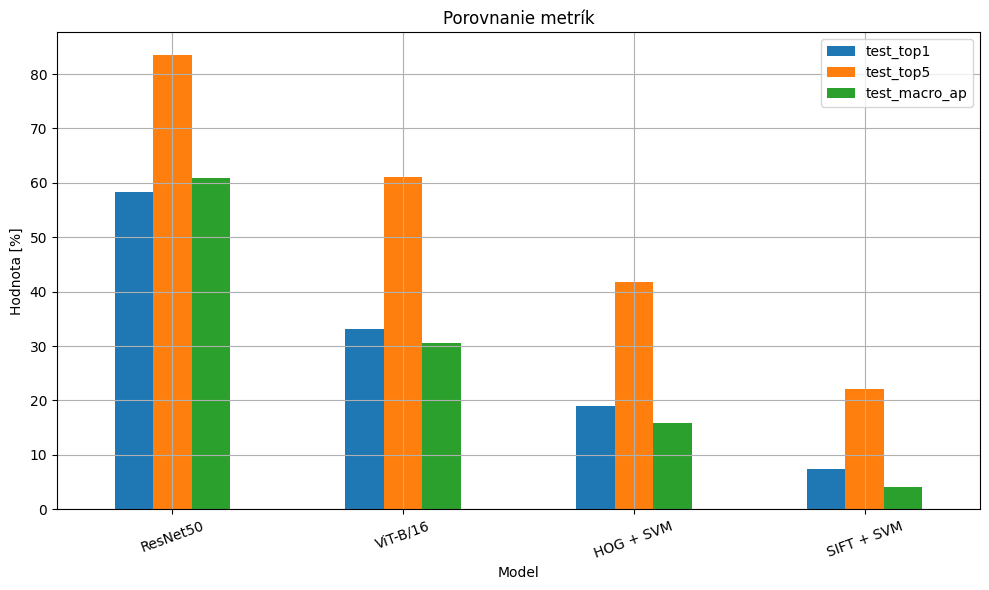

In [26]:
cifar_df, cifar_mean = run_full_analysis(
    "cifar100_results.csv",
    "CIFAR-100"
)

**CALTECH-256**

Najlepší Top-1 Acc : ResNet50 - 73.02%

Najhorší Top-1 Acc : SIFT + SVM - 11.64%

Najlepší Top-5 Acc : ResNet50 - 88.68%

Najhorší Top-5 Acc : SIFT + SVM - 23.13%

Najlepšie mAP : Resnet50 - 77.75%

Najhoršie mAP : SIFT + SVM - 3.59%

Najdlhšie trénovanie: HoG + SVM - 0h 59m 11s

Najkratšie trénovanie: SIFT + SVM - 0h 18m 46s

,model_name,test_top1,test_top5,test_macro_ap,val_top1,val_top5,val_macro_ap,train_time,final_train_loss,final_val_loss,best_val_loss,best_epoch,params_total,params_trainable,flops
0,ResNet50,73.02,88.68,77.75,75.67,90.39,81.05,0h 24m 26s,0.04,1.46,1.19,11.33,24034625.0,24034625.0,4.109991e+09
1,ViT-B/16,27.08,45.99,20.83,28.91,48.73,22.88,0h 37m 25s,0.16,6.12,4.15,11.33,85996289.0,85996289.0,1.686684e+10
2,HOG + SVM,14.31,27.18,8.46,13.62,26.56,8.17,0h 59m 11s,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SIFT + SVM,11.64,23.13,3.59,11.72,23.79,3.61,0h 18m 46s,NaN,NaN,NaN,NaN,NaN,NaN,NaN


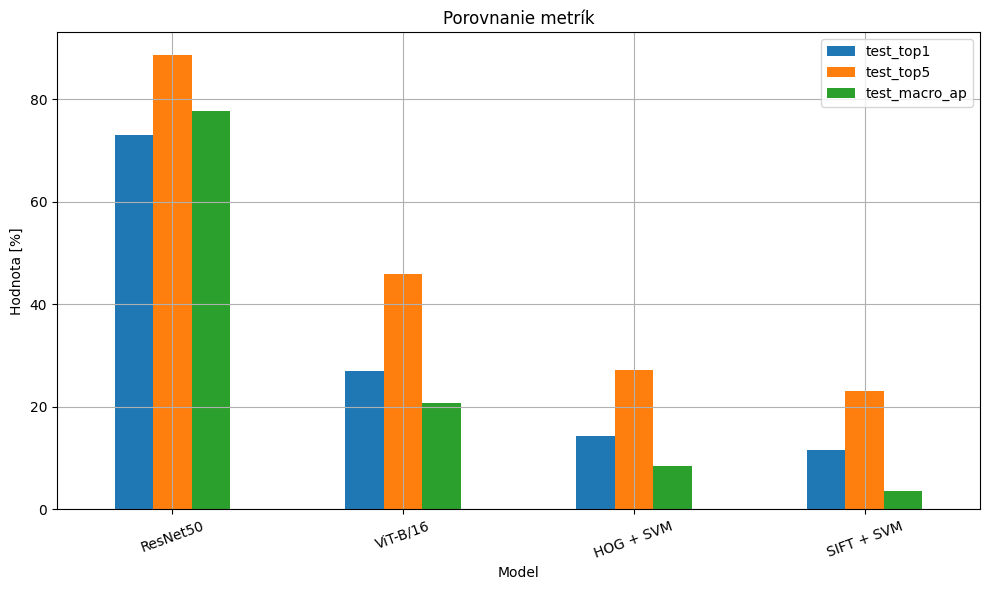

In [29]:
caltech_df, caltech_mean = run_full_analysis(
    "caltech256_results.csv",
    "Caltech-256"
)

**FOOD-101**

Najlepší Top-1 Acc : ResNet50 - 73.00%

Najhorší Top-1 Acc : HoG + SVM - 6.67%

Najlepší Top-5 Acc : ResNet50 - 90.39%

Najhorší Top-5 Acc : HoG + SVM - 19.99%

Najlepšie mAP : Resnet50 - 79.57%

Najhoršie mAP : HoG + SVM - 4.00%

Najdlhšie trénovanie: HoG + SVM - 4h 18m 19s

Najkratšie trénovanie: ResNet50 - 0h 52m 31s

,model_name,test_top1,test_top5,test_macro_ap,val_top1,val_top5,val_macro_ap,train_time,final_train_loss,final_val_loss,best_val_loss,best_epoch,params_total,params_trainable,flops
0,ResNet50,73.00,90.39,79.57,73.93,91.87,81.25,0h 52m 31s,0.04,1.55,1.12,6.00,23714981.0,23714981.0,4.109671e+09
1,ViT-B/16,42.21,68.84,41.98,43.63,71.52,46.17,1h 38m 9s,0.15,3.90,2.35,7.67,85876325.0,85876325.0,1.686672e+10
2,SIFT + SVM,11.18,30.14,6.68,11.64,30.70,6.93,3h 44m 37s,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HOG + SVM,6.67,19.99,4.00,6.87,20.47,4.08,4h 18m 19s,NaN,NaN,NaN,NaN,NaN,NaN,NaN


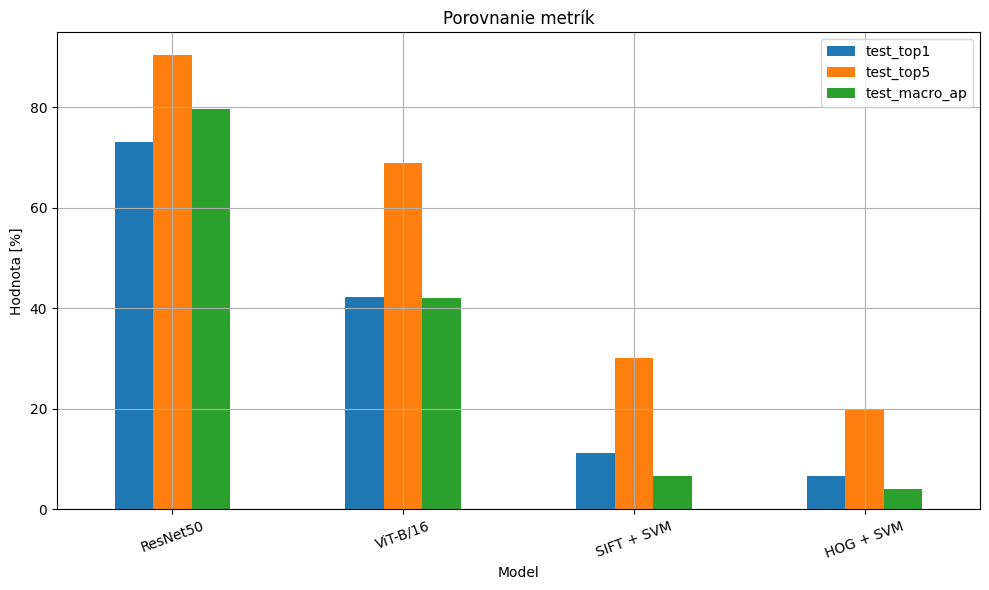

In [31]:
food_df, food_mean = run_full_analysis(
    "food101_results.csv",
    "Food-101"
)